<a href="https://www.kaggle.com/code/sonawanelalitsunil/e-commerce-analytics-ml-100?scriptVersionId=226744068" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/e-commerce-analytics-swiggy-zomato-blinkit/Ecommerce_Delivery_Analytics_New.csv


### Title: E-Commerce Analytics: Insights from Swiggy, Zomato & Blinkit

#### Description: Explore data-driven insights from Swiggy, Zomato, and Blinkit, covering customer behavior, order trends, and operational analytics to enhance e-commerce strategies.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('/kaggle/input/e-commerce-analytics-swiggy-zomato-blinkit/Ecommerce_Delivery_Analytics_New.csv')

# Display basic info
display(df.head())
display(df.info())
display(df.describe())
# Check for missing values
display(df.isnull().sum())

# Check for duplicate rows
display(df.duplicated().sum())

# Handle missing values
df.dropna(inplace=True)
df.dtypes
df.columns

,Order ID,Customer ID,Platform,Order Date & Time,Delivery Time (Minutes),Product Category,Order Value (INR),Customer Feedback,Service Rating,Delivery Delay,Refund Requested
0,ORD000001,CUST2824,JioMart,19:29.5,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No
1,ORD000002,CUST1409,Blinkit,54:29.5,16,Dairy,279,Quick and reliable!,5,No,No
2,ORD000003,CUST5506,JioMart,21:29.5,25,Beverages,599,Items missing from order.,2,No,Yes
3,ORD000004,CUST5012,JioMart,19:29.5,42,Beverages,946,Items missing from order.,2,Yes,Yes
4,ORD000005,CUST4657,Blinkit,49:29.5,30,Beverages,334,"Fast delivery, great service!",5,No,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Order ID                 100000 non-null  object
 1   Customer ID              100000 non-null  object
 2   Platform                 100000 non-null  object
 3   Order Date & Time        100000 non-null  object
 4   Delivery Time (Minutes)  100000 non-null  int64 
 5   Product Category         100000 non-null  object
 6   Order Value (INR)        100000 non-null  int64 
 7   Customer Feedback        100000 non-null  object
 8   Service Rating           100000 non-null  int64 
 9   Delivery Delay           100000 non-null  object
 10  Refund Requested         100000 non-null  object
dtypes: int64(3), object(8)
memory usage: 8.4+ MB


None

,Delivery Time (Minutes),Order Value (INR),Service Rating
count,100000.000000,100000.000000,100000.000000
mean,29.536140,590.994400,3.240790
std,9.958933,417.409058,1.575962
min,5.000000,50.000000,1.000000
25%,23.000000,283.000000,2.000000
50%,30.000000,481.000000,3.000000
75%,36.000000,770.000000,5.000000
max,76.000000,2000.000000,5.000000


Order ID                   0
Customer ID                0
Platform                   0
Order Date & Time          0
Delivery Time (Minutes)    0
Product Category           0
Order Value (INR)          0
Customer Feedback          0
Service Rating             0
Delivery Delay             0
Refund Requested           0
dtype: int64

0

Index(['Order ID', 'Customer ID', 'Platform', 'Order Date & Time',
       'Delivery Time (Minutes)', 'Product Category', 'Order Value (INR)',
       'Customer Feedback', 'Service Rating', 'Delivery Delay',
       'Refund Requested'],
      dtype='object')

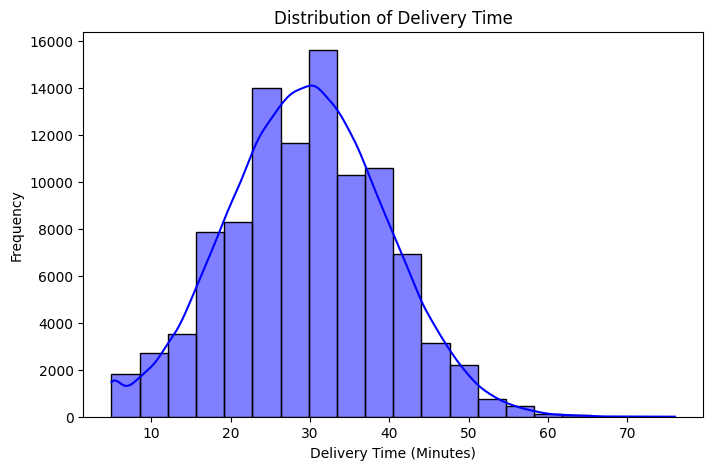

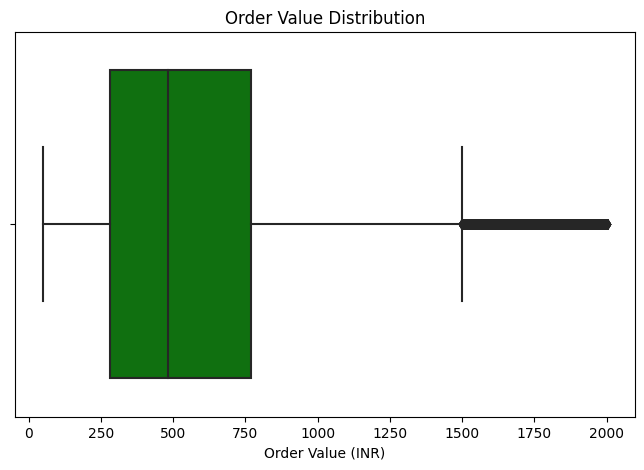

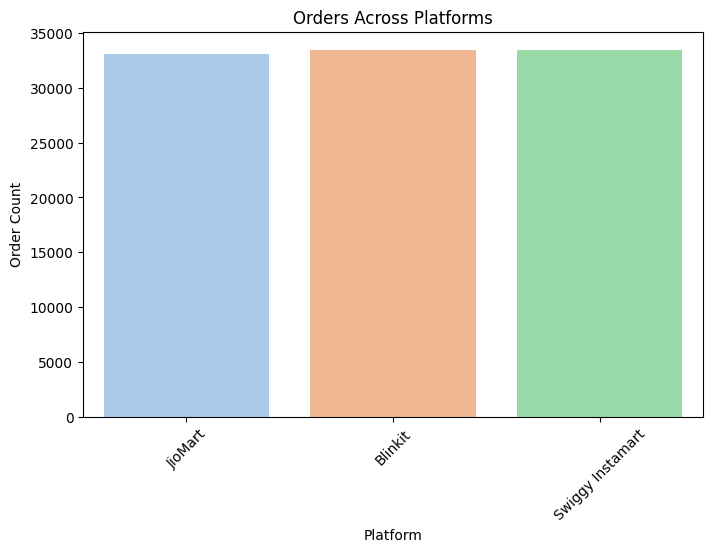

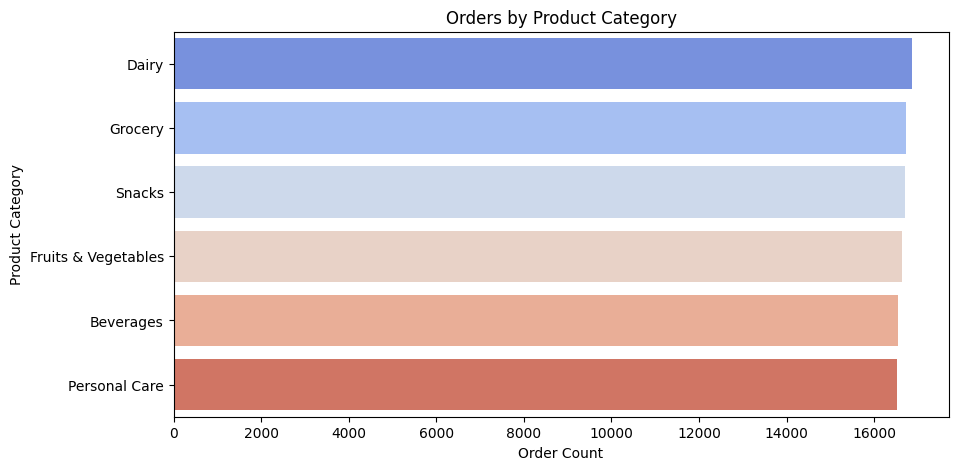

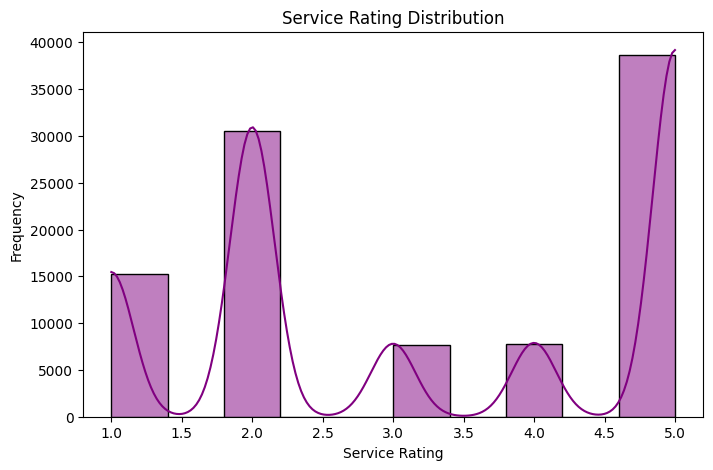

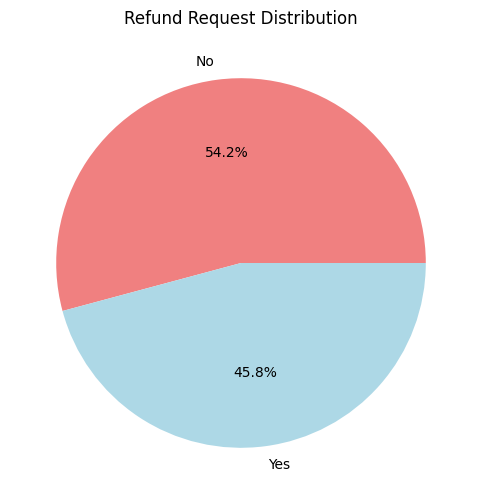

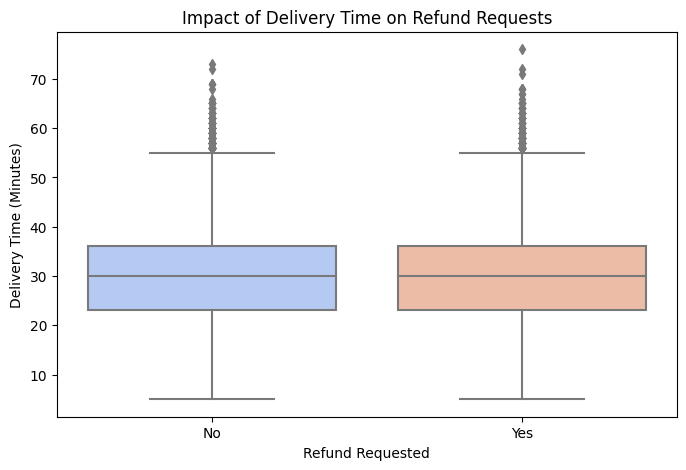

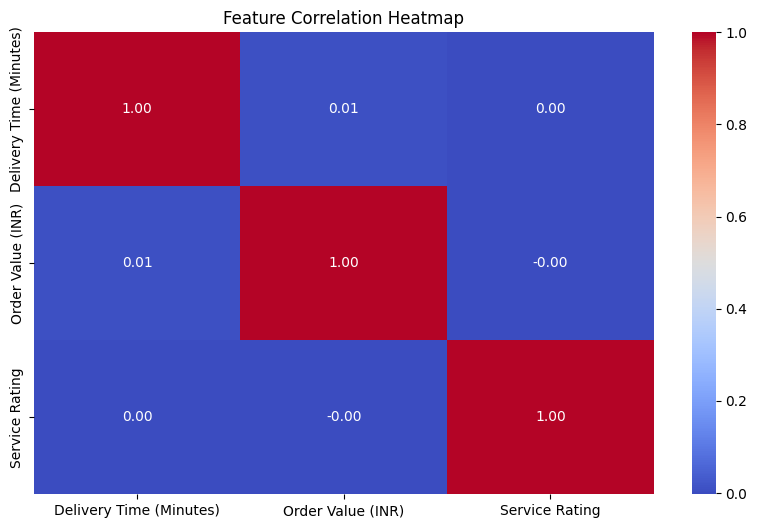

In [3]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Delivery Time (Minutes)'], bins=20, kde=True, color='blue')
plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (Minutes)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Order Value (INR)'], color='green')
plt.title('Order Value Distribution')
plt.xlabel('Order Value (INR)')
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Platform', palette='pastel')
plt.title('Orders Across Platforms')
plt.xlabel('Platform')
plt.ylabel('Order Count')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='Product Category', order=df['Product Category'].value_counts().index, palette='coolwarm')
plt.title('Orders by Product Category')
plt.xlabel('Order Count')
plt.ylabel('Product Category')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df['Service Rating'], bins=10, kde=True, color='purple')
plt.title('Service Rating Distribution')
plt.xlabel('Service Rating')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(6, 6))
df['Refund Requested'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightcoral', 'lightblue'])
plt.title('Refund Request Distribution')
plt.ylabel('')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Refund Requested'], y=df['Delivery Time (Minutes)'], palette='coolwarm')
plt.title('Impact of Delivery Time on Refund Requests')
plt.xlabel('Refund Requested')
plt.ylabel('Delivery Time (Minutes)')
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

## Predictive modeling

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
df['Refund Requested']=df['Refund Requested'].map({'No':0,'Yes':1})
df['Delivery Delay']=df['Delivery Delay'].map({'No':0,'Yes':1})

In [6]:
df.drop(['Order ID', 'Customer ID', 'Order Date & Time'], axis=1, inplace=True)

In [7]:
# Encoding categorical features
categorical_cols = ['Platform', 'Product Category', 'Customer Feedback']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Splitting Features and Target
X = df.drop(columns=['Refund Requested'])
y = df['Refund Requested']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Dictionary to store models and results
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# Training and Evaluating Models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"🔹 {name}: Accuracy = {acc:.4f}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("-" * 50)


🔹 Logistic Regression: Accuracy = 1.0000
[[10836     0]
 [    0  9164]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10836
           1       1.00      1.00      1.00      9164

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

--------------------------------------------------
🔹 Decision Tree: Accuracy = 1.0000
[[10836     0]
 [    0  9164]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10836
           1       1.00      1.00      1.00      9164

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

--------------------------------------------------
🔹 Random Forest: Accuracy = 1.0000
[[10836     0]
 [    0  9164]]
              precision    recall  f1-sc

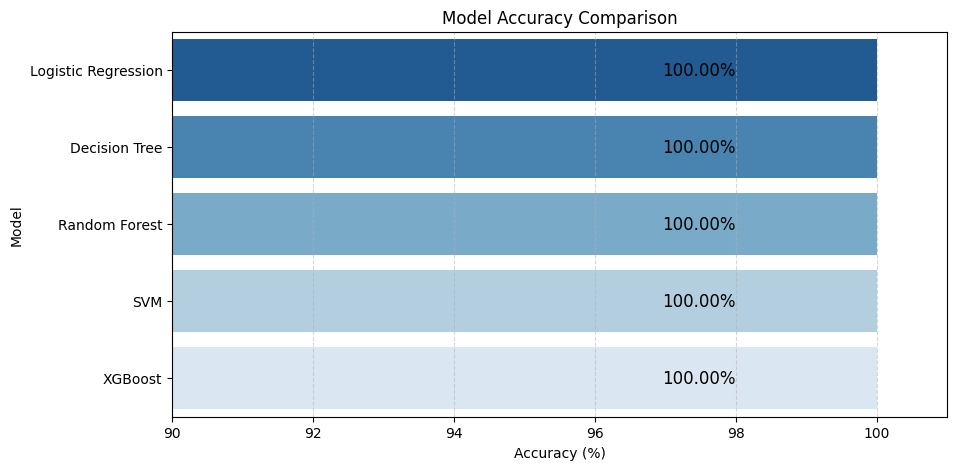

In [8]:
results = {
    "Logistic Regression": 1.0,
    "Decision Tree": 1.0,
    "Random Forest": 1.0,
    "SVM": 1.0,
    "XGBoost": 1.0
}

# Convert to percentage
model_names = list(results.keys())
accuracies = [acc * 100 for acc in results.values()]

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=accuracies, y=model_names, palette="Blues_r")

# Add value labels
for index, value in enumerate(accuracies):
    plt.text(value - 2, index, f"{value:.2f}%", va='center', ha='right', fontsize=12, color='black')

# Titles and labels
plt.xlabel("Accuracy (%)")
plt.ylabel("Model")
plt.title("Model Accuracy Comparison")
plt.xlim(90, 101)  # Focus on high accuracy range
plt.grid(axis='x', linestyle="--", alpha=0.5)
plt.show()


## Thank you!!!!!!.....pls upvotes!!!!!!!